# LLM Sentiment Analysis Benchmark Pipeline
This notebook serves as a complete pipeline to benchmark various Large Language Models (LLMs) on a Persian Sentiment Analysis task.

**Workflow Overview:**
1. **Setup & Configurations:** Import libraries and define global constants.
2. **Dataset Preparation:** Filter the ground-truth dataset to a specific subset (e.g., 200 rows).
3. **Automated API Execution:** Send batched requests to Azure AI models and save results.
4. **Missing Data Audit:** Check for rows that failed due to API timeouts, rate limits, or JSON formatting errors.
5. **Interactive Manual Runner:** A fallback tool to manually query models (via copy-pasting prompts) to fill in missing gaps or test new models.
6. **Evaluation & Metrics:** Calculate Accuracy, Precision, Recall, and F1-Score to generate a final leaderboard.

# Install dependencies
All the following packages are needed in order to to make this jupyter fully functional.

```bash
pip install -r requirements.txt
```

In [ ]:
import os
import re
import csv
import json
import time
import glob
import random
import pandas as pd
import concurrent.futures
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

try:
    import pyperclip
    HAS_CLIP = True
except ImportError:
    HAS_CLIP = False

# Global Configurations
MAIN_CSV = "data/downsample_balanced_binary_label_50.csv"
RESULTS_DIR = "./Sentiment_Results"
MAX_ROWS = 200
BATCH_SIZE = 200

# Ensure the main results directory exists
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Libraries imported and global configurations set.")

## Step 1: Automated LLM Inference (Azure API)
This section automatically connects to the Azure AI Inference endpoints to fetch sentiment predictions. Since APIs can face rate limits and timeouts, we use multithreading and automatic key rotation.

**What this code does:**
- Divides the dataset into manageable batches.
- Checks if a batch is already processed (to prevent redundant API calls).
- Sends prompts to the selected models asking for a strictly formatted JSON array.
- Retries failed requests up to a maximum limit and logs persistently failed batches into a root log file.
- Saves valid responses inside model-specific subdirectories (e.g., `./Sentiment_Results/Ministral-3B/`).

In [ ]:
from azure.ai.inference import ChatCompletionsClient
from azure.core.credentials import AzureKeyCredential

MAX_RETRIES = 3
REQUEST_TIMEOUT = 45
ERROR_LOG_FILE = os.path.join(RESULTS_DIR, f"failed_batches_log_batch_{BATCH_SIZE}.csv")

API_KEYS = [
    "...",
    "...",
]

MODELS_TO_RUN = [
    {"name": "gpt-4.1", "rpm": 10},
]

global_executor = concurrent.futures.ThreadPoolExecutor(max_workers=10)

class AzureText:
    def __init__(self, model_name, rpm):
        self.model = model_name
        self.rpm = rpm
        self.keys = API_KEYS
        self.current_key_idx = 0
        self.setup_client()

    def setup_client(self):
        if self.keys[self.current_key_idx]:
            self.client = ChatCompletionsClient(
                endpoint="https://models.inference.ai.azure.com",
                credential=AzureKeyCredential(self.keys[self.current_key_idx]),
            )

    def rotate_key(self):
        self.current_key_idx = (self.current_key_idx + 1) % len(self.keys)
        self.setup_client()

    def _make_api_call(self, prompt):
        return self.client.complete(
            messages=[{"role": "user", "content": prompt}],
            model=self.model,
            temperature=0.0,
        )

    def generate_text(self, prompt):
        try:
            future = global_executor.submit(self._make_api_call, prompt)
            response = future.result(timeout=REQUEST_TIMEOUT)
            return {"message": response.choices[0].message.content, "has_error": False, "is_rate_limit": False}
        except concurrent.futures.TimeoutError:
            return {"message": f"Timeout! No response in {REQUEST_TIMEOUT}s.", "has_error": True, "is_rate_limit": False}
        except Exception as e:
            error_msg = str(e).lower()
            is_rate_limit = "429" in error_msg or "rate limit" in error_msg or "quota" in error_msg
            return {"message": str(e), "has_error": True, "is_rate_limit": is_rate_limit}

def extract_json(text):
    try:
        match = re.search(r'```(?:json)?(.*?)```', text, re.DOTALL)
        if match:
            return json.loads(match.group(1).strip())
        start_idx = text.find('[')
        end_idx = text.rfind(']')
        if start_idx != -1 and end_idx != -1:
            return json.loads(text[start_idx:end_idx+1])
        return json.loads(text.strip())
    except Exception:
        return None

def get_processed_ids(filename):
    if not os.path.exists(filename):
        return set()
    with open(filename, mode='r', encoding='utf-8') as f:
        return set(row['id'] for row in csv.DictReader(f))

def save_results(filename, results_list):
    file_exists = os.path.exists(filename)
    with open(filename, mode='a', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['id', 'sentiment', 'raw_text'])
        if not file_exists:
            writer.writeheader()
        writer.writerows(results_list)

def log_failed_batch(model_name, batch_ids, reason):
    file_exists = os.path.exists(ERROR_LOG_FILE)
    with open(ERROR_LOG_FILE, mode='a', encoding='utf-8', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(['Timestamp', 'Model', 'Batch_Size', 'First_ID', 'Last_ID', 'Reason'])
        writer.writerow([time.strftime("%Y-%m-%d %H:%M:%S"), model_name, len(batch_ids), batch_ids[0], batch_ids[-1], reason])

dataset = []
df = pd.read_csv(MAIN_CSV)
for idx, row in df.iterrows():
    if pd.notna(row.get('Text')):
        dataset.append({"id": f"row_{idx}", "text": str(row['Text'])})

if API_KEYS[0]:
    clients = {m["name"]: AzureText(m["name"], m["rpm"]) for m in MODELS_TO_RUN}
    for i in range(0, len(dataset), BATCH_SIZE):
        batch_data = dataset[i : i + BATCH_SIZE]
        batch_ids = [item['id'] for item in batch_data]

        for m in MODELS_TO_RUN:
            model_name = m["name"]
            llm = clients[model_name]

            model_dir = os.path.join(RESULTS_DIR, model_name)
            os.makedirs(model_dir, exist_ok=True)
            output_csv = os.path.join(model_dir, f"{model_name}-batch-{BATCH_SIZE}.csv")

            processed_ids = get_processed_ids(output_csv)
            unprocessed_batch = [item for item in batch_data if item['id'] not in processed_ids]

            if not unprocessed_batch:
                continue

            reviews_text = "\n".join([f"ID: {item['id']} | Text: {item['text']}" for item in unprocessed_batch])
            prompt = f"You are an expert sentiment analyzer. Read the following Persian texts and classify the sentiment of each as either 1 (Positive) or 0 (Negative).\nYou MUST output ONLY a valid JSON array. Do not include any other text or explanation.\nThe JSON format must strictly match this structure:\n[\n  {{\"id\": \"row_id\", \"sentiment\": 1 or 0}}\n]\n\nTexts:\n{reviews_text}"

            success = False
            fail_reason = "Failed after max retries"

            for attempt in range(MAX_RETRIES):
                result = llm.generate_text(prompt)
                if result["has_error"]:
                    if result.get("is_rate_limit"):
                        llm.rotate_key()
                    time.sleep(5)
                    continue

                parsed_json = extract_json(result["message"])
                if parsed_json is None:
                    fail_reason = "JSON Error"
                    break

                if len(parsed_json) != len(unprocessed_batch):
                    fail_reason = f"Mismatch: Expected {len(unprocessed_batch)}, Got {len(parsed_json)}"
                    time.sleep(5)
                    continue

                to_save = []
                for item in parsed_json:
                    orig_text = next((d['text'] for d in unprocessed_batch if str(d['id']) == str(item.get('id'))), "")
                    to_save.append({'id': item.get('id'), 'sentiment': item.get('sentiment'), 'raw_text': orig_text})

                save_results(output_csv, to_save)
                success = True
                time.sleep(60.0 / llm.rpm)
                break

            if not success:
                log_failed_batch(model_name, batch_ids, fail_reason)
else:
    print("API keys not provided. Skipping automated inference step.")

## Step 2: Missing Data Detection
LLM endpoints are unpredictable. Sometimes they hallucinate responses, return invalid JSONs, or time out.

**What this code does:**
- It scans all model subdirectories inside `Sentiment_Results`.
- It calculates the difference between the expected target IDs (`row_0` to `row_199`) and the actual processed IDs.
- Outputs a report identifying exactly which models failed on which specific rows.

In [ ]:
all_expected_ids = {f"row_{i}" for i in range(MAX_ROWS)}

csv_files = glob.glob(os.path.join(RESULTS_DIR, "*", "*.csv"))

missing_report = {}

for file in csv_files:
    model_name = os.path.basename(file).replace(".csv", "")
    df = pd.read_csv(file)

    if 'id' not in df.columns:
        continue

    processed_ids = set(df['id'].astype(str))
    missing_ids = all_expected_ids - processed_ids

    if missing_ids:
        missing_report[model_name] = sorted(
            missing_ids,
            key=lambda x: int(x.split('_')[1])
        )

report_path = "missing_ids_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    if not csv_files:
        f.write("No output files found.\n")
    elif not missing_report:
        f.write("All models have processed 100% of the dataset.\n")
    else:
        for model, m_ids in missing_report.items():
            f.write(
                f"Model: {model}\n"
                f"Missing Count: {len(m_ids)}\n"
                f"Missing IDs: {', '.join(m_ids)}\n"
            )
            f.write("-" * 50 + "\n")

## Step 3: Interactive Manual Runner
For models where we don't have access to their API key (e.g., interacting directly with ChatGPT Web UI, Claude Web UI) or to fix missing gaps, we use an interactive cell.

**What this code does:**
- Asks for a model name and batch size.
- Automatically generates the prompt for missing IDs and copies it to your clipboard.
- Waits for you to paste the JSON response back.
- Validates the structure and saves it properly into `Sentiment_Results/[model_name]/[model_name]-batch-[size].csv`.

*Note: Since Jupyter Notebooks block execution on `input()`, run this cell only when you are actively manually fetching data.*

In [ ]:
def interactive_runner():
    df_main_ref = pd.read_csv(MAIN_CSV)
    id_col = 'ID' if 'ID' in df_main_ref.columns else 'id'
    text_lookup = dict(zip(df_main_ref[id_col].astype(str), df_main_ref['Text']))

    model_name = input("Model Name: ").strip()
    if model_name.lower() in ['q', 'exit', 'quit'] or not model_name:
        return

    batch_size_str = input("Batch Size: ").strip()

    try:
        batch_size = int(batch_size_str)
        if batch_size <= 0:
            raise ValueError
    except ValueError:
        return

    model_dir = os.path.join(RESULTS_DIR, model_name)
    os.makedirs(model_dir, exist_ok=True)

    file_path = os.path.join(
        model_dir,
        f"{model_name}-batch-{batch_size}.csv"
    )

    if os.path.exists(file_path):
        df_model = pd.read_csv(file_path)
        processed_ids = set(df_model["id"].astype(str))
    else:
        df_model = pd.DataFrame(columns=["id", "sentiment", "raw_text"])
        processed_ids = set()

    target_ids = [f"row_{i}" for i in range(MAX_ROWS)]
    remaining_ids = [x for x in target_ids if x not in processed_ids]

    if not remaining_ids:
        return

    def local_parse(txt):
        txt = re.sub(r"```(?:json)?", "", txt).replace("```", "").strip()

        try:
            return json.loads(txt)
        except:
            match = re.search(r"\[.*\]", txt, re.DOTALL)

            if match:
                try:
                    return json.loads(match.group(0))
                except:
                    return None

            return None

    index = 0

    while index < len(remaining_ids):
        sub_batch_ids = remaining_ids[index:index + batch_size]
        current_batch_len = len(sub_batch_ids)

        reviews_text = "\n".join(
            f"ID: {bid} | Text: {text_lookup[bid]}"
            for bid in sub_batch_ids
        )

        prompt = (
            "You are an expert sentiment analyzer. Read the following Persian texts and classify the sentiment of each as either 1 (Positive) or 0 (Negative).\n"
            "You MUST output ONLY a valid JSON array. Do not include any other text or explanation.\n"
            "The JSON format must strictly match this structure:\n"
            "[\n"
            '  {"id": "row_id", "sentiment": 1 or 0}\n'
            "]\n\n"
            f"Texts:\n{reviews_text}"
        )

        if HAS_CLIP:
            try:
                pyperclip.copy(prompt)
            except:
                pass

        print(prompt)

        cmd = input().strip()

        if cmd.lower() in ["q", "quit", "exit"]:
            return

        if cmd == "-1":
            sentiments = [
                random.choice([0, 1])
                for _ in range(current_batch_len)
            ]
        else:
            raw_json_input = pyperclip.paste()
            parsed_json = local_parse(raw_json_input)

            while True:
                if parsed_json is not None:
                    pred_map = {
                        str(item.get("id")): item.get("sentiment")
                        for item in parsed_json
                        if isinstance(item, dict) and "id" in item
                    }

                    if all(bid in pred_map for bid in sub_batch_ids):
                        try:
                            sentiments = [
                                int(float(pred_map[bid]))
                                for bid in sub_batch_ids
                            ]
                            break
                        except:
                            pass

                retry = input().strip()

                if retry.lower() in ["q", "quit", "exit"]:
                    return

                raw_json_input = pyperclip.paste()
                parsed_json = local_parse(raw_json_input)

        rows = [
            {
                "id": bid,
                "sentiment": sentiments[i],
                "raw_text": text_lookup[bid]
            }
            for i, bid in enumerate(sub_batch_ids)
        ]

        df_model = pd.concat(
            [df_model, pd.DataFrame(rows)],
            ignore_index=True
        )

        def sk(row_id):
            try:
                return int(str(row_id).split("_")[1])
            except:
                return 999999

        df_model["temp_sort"] = df_model["id"].apply(sk)

        df_model = (
            df_model
            .sort_values("temp_sort")
            .drop(columns=["temp_sort"])
            .reset_index(drop=True)
        )

        df_model.to_csv(file_path, index=False)

        index += current_batch_len


interactive_runner()

## Step 4: Final Evaluation & Metrics
This is the final phase of the pipeline. Now that we have multiple complete evaluations from different models and batch sizes, we need to compare them to the Ground Truth.

**What this code does:**
- Loads the true labels from `MAIN_CSV`.
- Recursively traverses through `./Sentiment_Results/*/*.csv` to load all model predictions.
- Synchronizes IDs and calculates **Accuracy**, **Precision**, **Recall**, and **F1-Score**.
- Sorts the models descending by F1-Score and exports `final_evaluation_metrics.csv`.

In [24]:
import os
import glob
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load ground truth labels from the main dataset
print("Loading ground truth labels from the main dataset...")
df_main_eval = pd.read_csv(MAIN_CSV)
id_col_eval = 'ID' if 'ID' in df_main_eval.columns else 'id'

# Optimize set creation using set comprehension
valid_ids_eval = {f"row_{i}" for i in range(MAX_ROWS)}
truth_dict = {}

for _, row in df_main_eval.iterrows():
    row_id = str(row[id_col_eval])
    if row_id in valid_ids_eval:
        val = row.get('binary_label')
        if pd.notna(val):
            truth_dict[row_id] = int(float(val))

print(f"Loaded {len(truth_dict)} ground truth rows.")

# Find all model output files excluding failed ones
eval_csv_files = glob.glob(os.path.join(RESULTS_DIR, "*", "*.csv"))
eval_csv_files = [f for f in eval_csv_files if "failed" not in os.path.basename(f).lower()]

# Determine the provider using match-case with guard clauses for substring matching
def get_provider(model_name):
    # Convert to lowercase to ensure case-insensitive matching
    name = model_name.lower()

    match name:
        case _ if any(m in name for m in ["gpt-4.1", "gpt-4o", "llama-3.3", "ministral"]):
            return "Azure"
        case _ if any(m in name for m in ["claude", "deepseek", "gpt-o4-mini"]):
            return "GapGPT"
        case _ if "gpt-5.5" in name:
            return "OpenAI"
        case _ if "gemini" in name:
            return "Google"
        case _ if "grok" in name:
            return "xAI"
        case _:
            return "Unknown"

eval_results = []

for file_path in eval_csv_files:
    filename = os.path.basename(file_path)
    # Extract base name without extension
    model_name = filename.replace(".csv", "")
    df_model_eval = pd.read_csv(file_path)

    y_true = []
    y_pred = []

    # Assign provider using the match-case function
    provider = get_provider(model_name)

    # Sync predictions with ground truth
    for _, row in df_model_eval.iterrows():
        if 'id' in row:
            row_id = str(row['id'])
            if row_id in truth_dict:
                pred_val = row.get('sentiment')
                if pd.notna(pred_val):
                    try:
                        y_pred.append(int(float(pred_val)))
                        y_true.append(truth_dict[row_id])
                    except ValueError:
                        pass

    # Calculate standard NLP Metrics
    if len(y_true) > 0:
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='binary', zero_division=0)
        rec = recall_score(y_true, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

        eval_results.append({
            "Model_File": model_name,
            "Provider": provider,
            "Rows": len(y_true),
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1-Score": round(f1, 4)
        })

# Sort and output results
df_res = pd.DataFrame(eval_results)

if not df_res.empty:
    df_res = df_res.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

    print("\n" + "=" * 105)
    print("AI Models Evaluation Leaderboard (Sorted by F1-Score)")
    print("=" * 105)
    print(df_res.to_string(index=False))
    print("=" * 105)

    output_name = "final_evaluation_metrics.csv"
    df_res.to_csv(output_name, index=False)
    print(f"\nResults successfully exported to '{output_name}'.")
else:
    print(f"Error: No valid data found in '{RESULTS_DIR}' or its subdirectories.")

Loading ground truth labels from the main dataset...
Loaded 200 ground truth rows.

AI Models Evaluation Leaderboard (Sorted by F1-Score)
                      Model_File Provider  Rows  Accuracy  Precision  Recall  F1-Score
                 gpt-4o-batch-10    Azure   200     0.915     0.9245  0.9159    0.9202
      claude-4.6-sonnet-batch-50   GapGPT   200     0.905     0.9074  0.9159    0.9116
     claude-4.6-sonnet-batch-100   GapGPT   200     0.905     0.9151  0.9065    0.9108
      claude-4.6-sonnet-batch-20   GapGPT   200     0.900     0.9065  0.9065    0.9065
                 gpt-4o-batch-20    Azure   200     0.895     0.8981  0.9065    0.9023
       claude-4.6-sonnet-batch-3   GapGPT   200     0.895     0.9057  0.8972    0.9014
             gpt-4o-mini-batch-3    Azure   200     0.895     0.9135  0.8879    0.9005
            gpt-4o-mini-batch-10    Azure   200     0.895     0.9216  0.8785    0.8995
 Llama-3.3-70B-Instruct-batch-20    Azure   200     0.890     0.8899  0.9065   

## Step 5: Visualizing Model Performance and Batch Size Impact
In this final step, we load the `final_evaluation_metrics.csv` file generated in the previous step. We will plot three key visualizations:
1. **Top 15 Configurations:** A bar chart showing the absolute best combinations of models and batch sizes.
2. **Impact of Batch Size:** A line chart showing how changing the batch size (3, 10, 20, 50, 100) affects the F1-Score for each specific LLM.
3. **Precision vs. Recall Trade-off:** A scatter plot to see if models lean more towards false positives or false negatives.

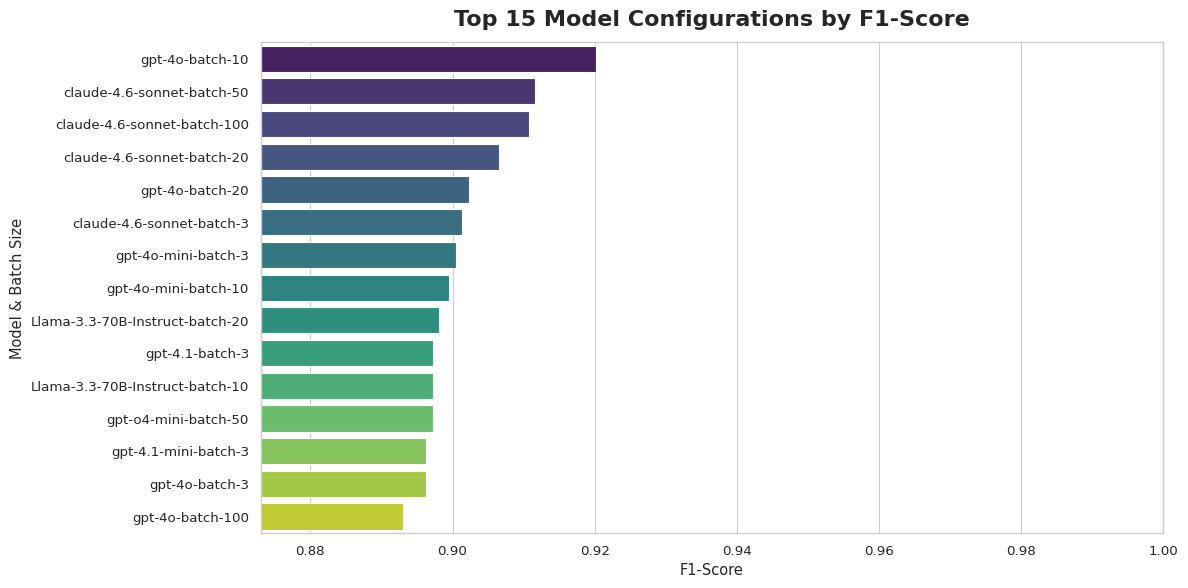

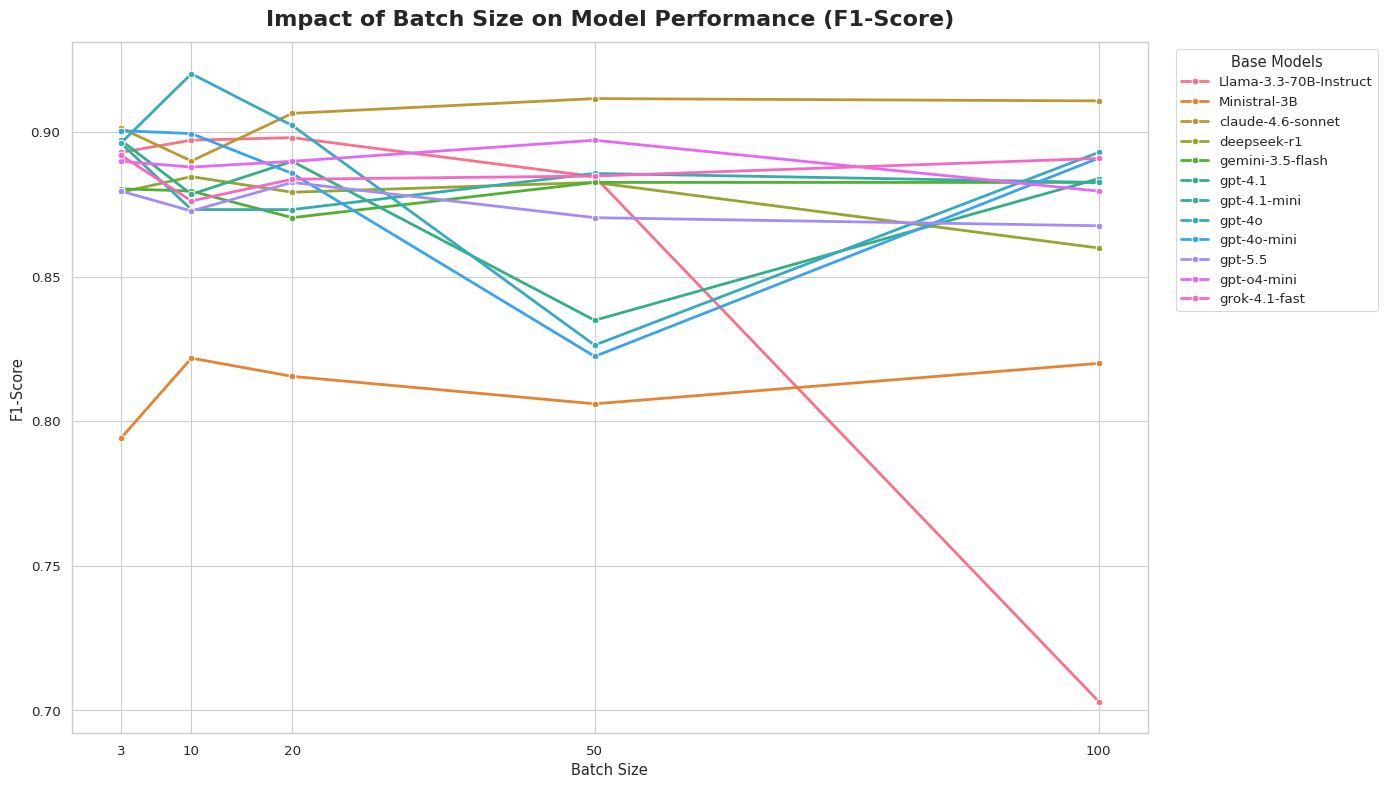

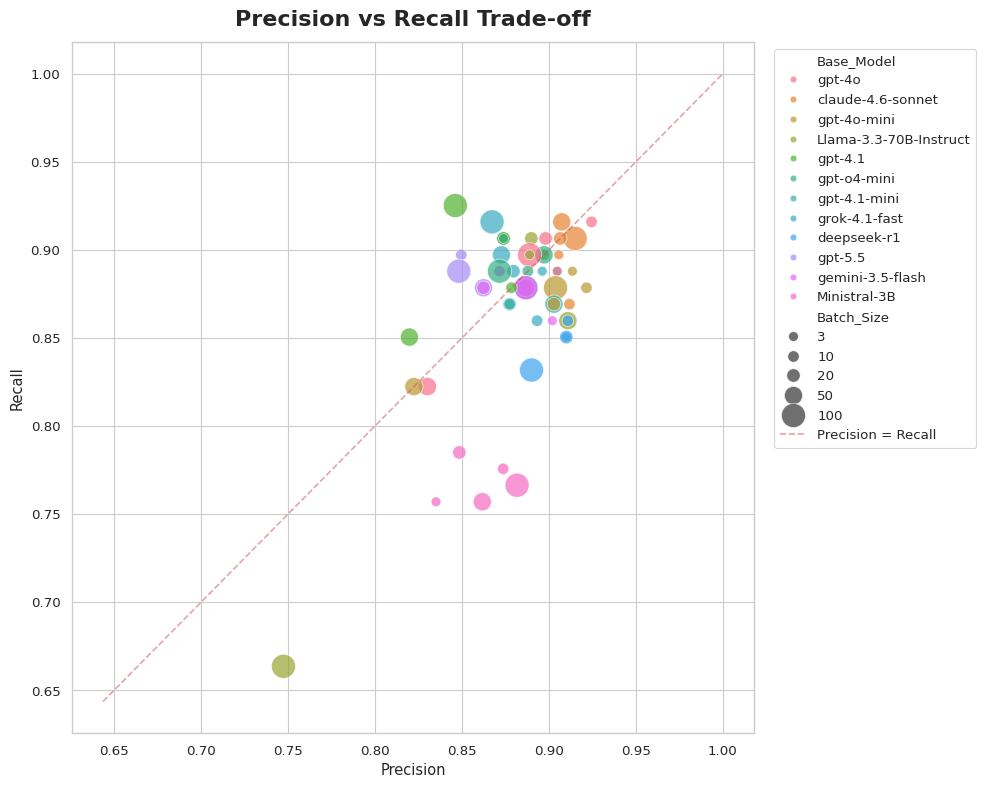

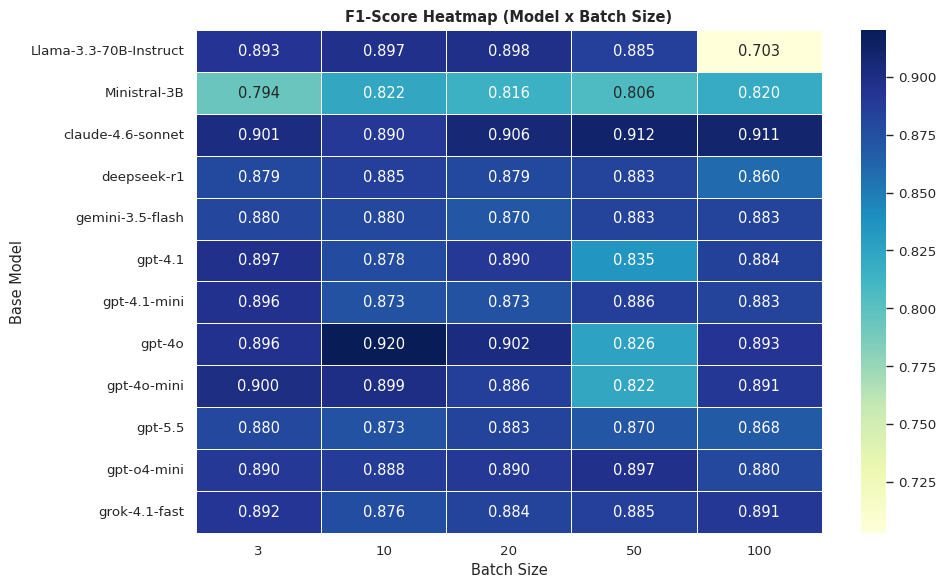

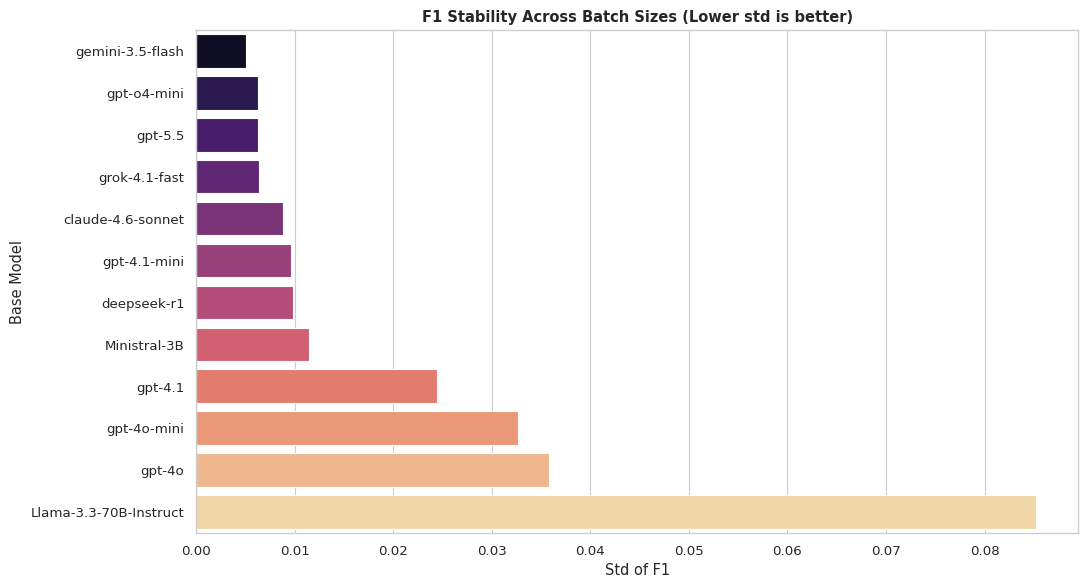

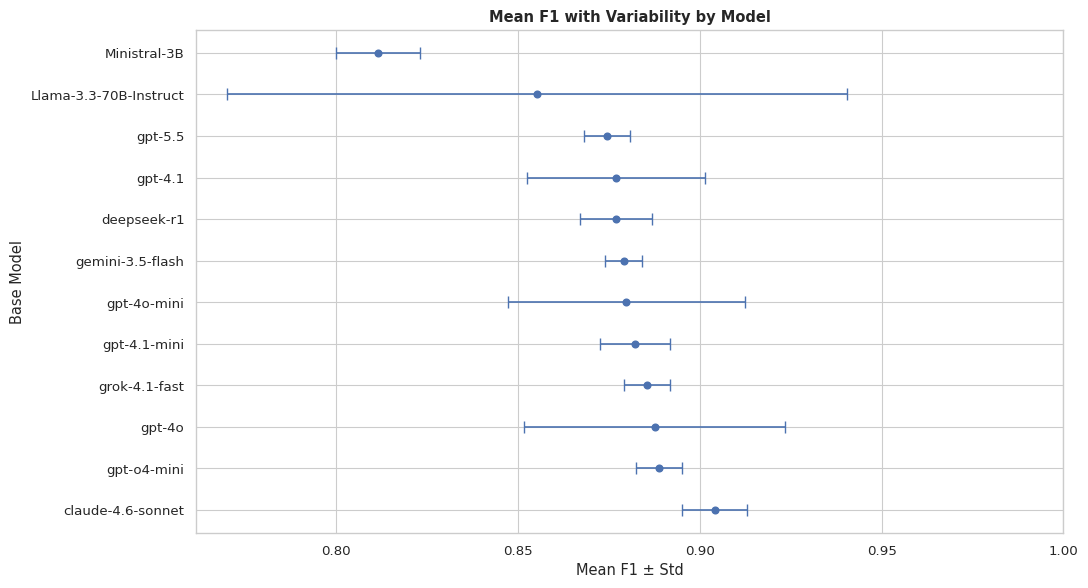

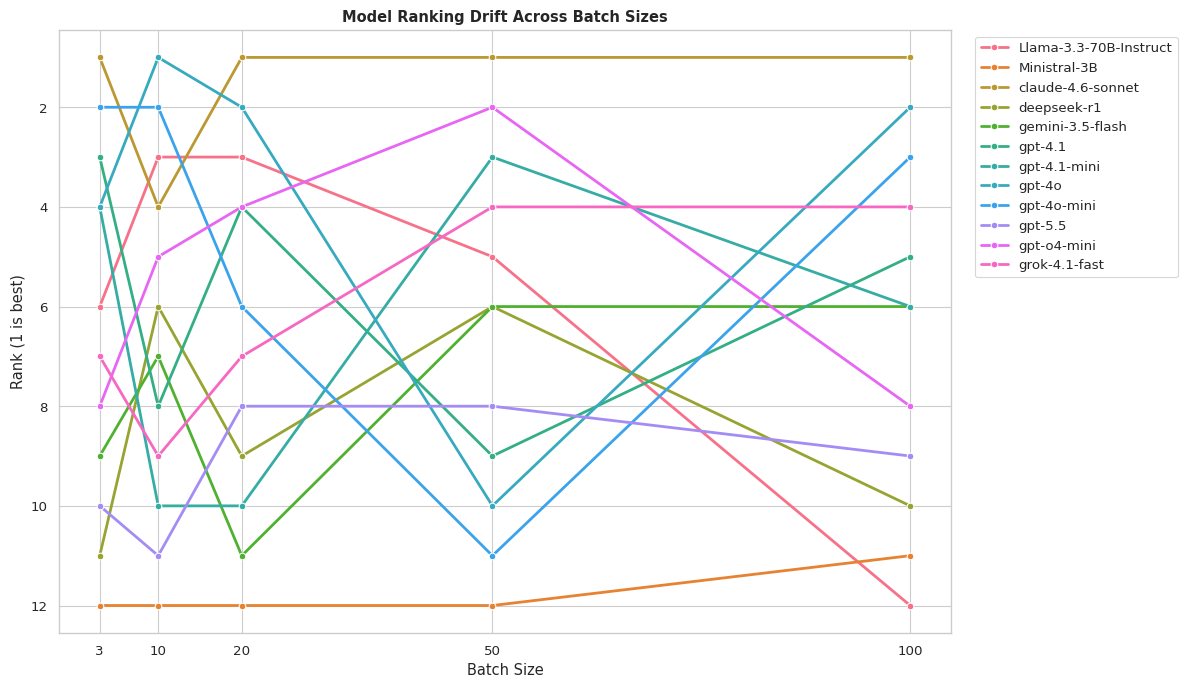

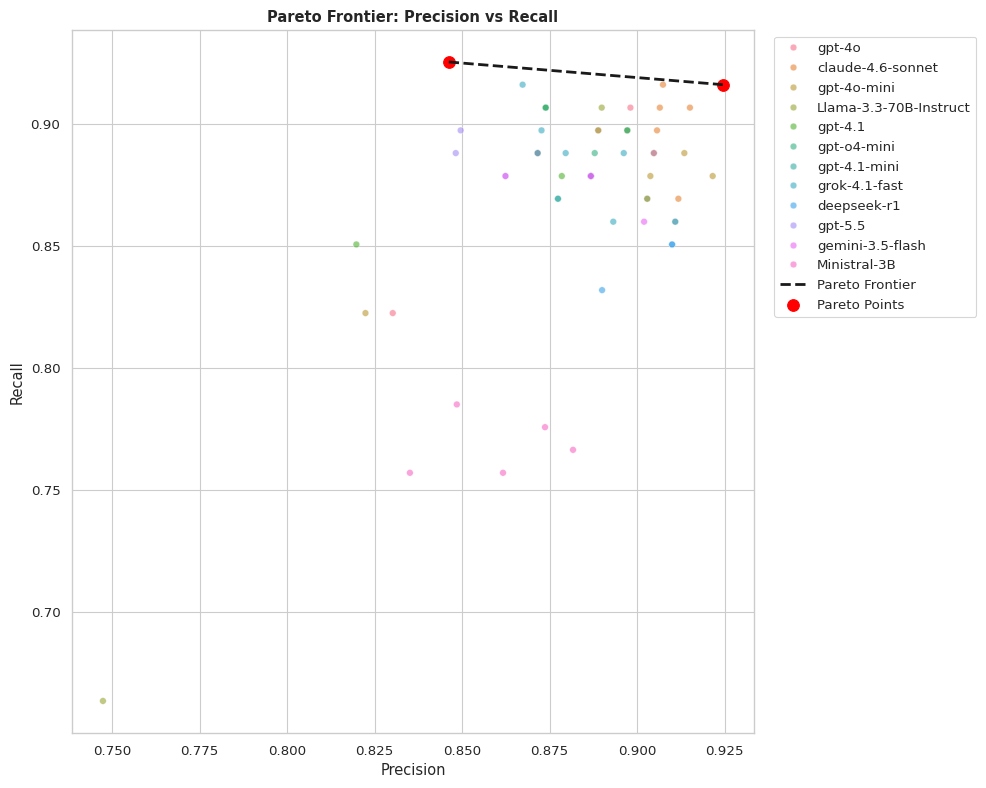

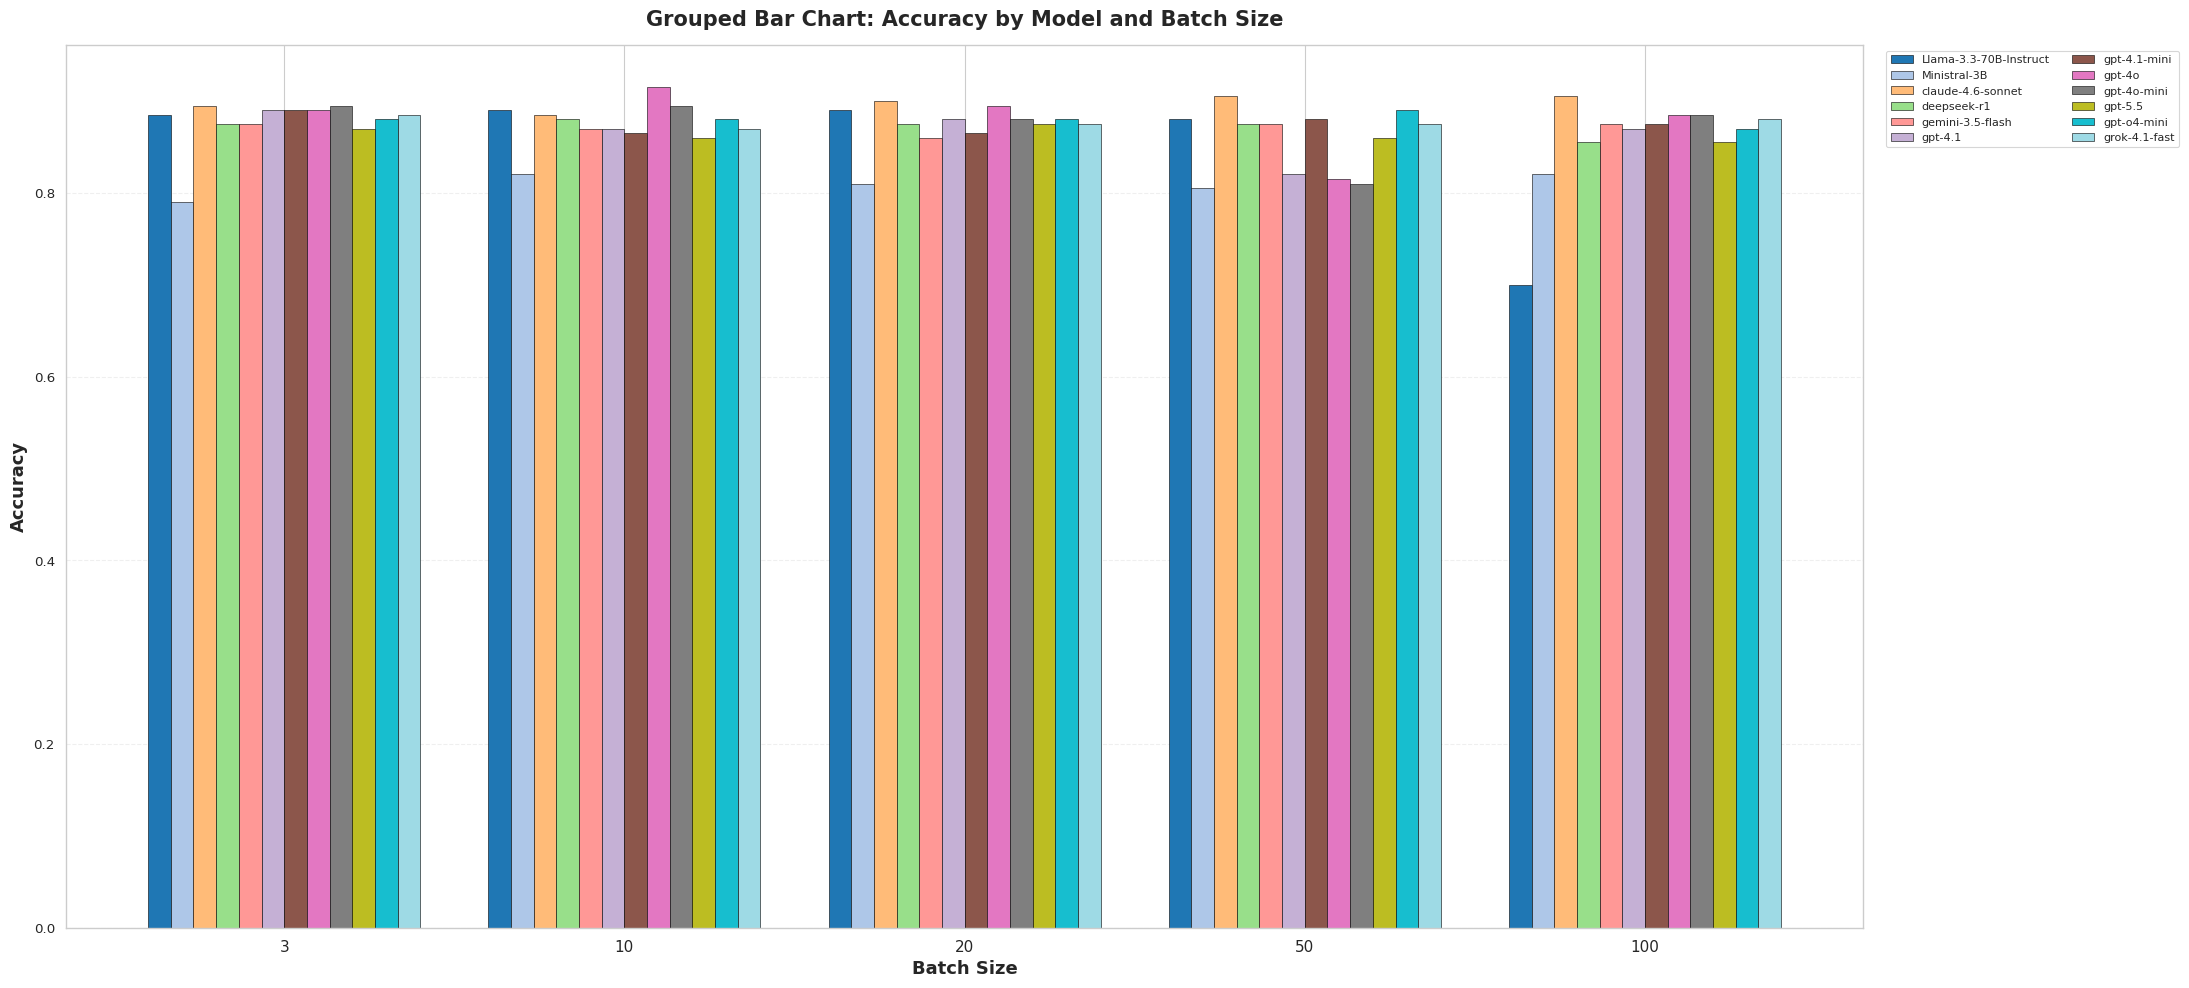

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load file
eval_file = "final_evaluation_metrics.csv"
if not os.path.exists(eval_file):
    raise FileNotFoundError(f"{eval_file} not found. Put it in the current working directory.")

df = pd.read_csv(eval_file)

# Validate required columns
required_cols = ["Model_File", "Accuracy", "Precision", "Recall", "F1-Score"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Extract base model and batch size
df["Base_Model"] = df["Model_File"].str.replace(r"-batch-\d+$", "", regex=True)
df["Batch_Size"] = df["Model_File"].str.extract(r"batch-(\d+)").astype(float).fillna(0).astype(int)

# Sort by F1 for ranking-style plots
df = df.sort_values("F1-Score", ascending=False).reset_index(drop=True)

# Theme
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# 1) Top 15 configurations by F1
plt.figure(figsize=(12, 6))
top_15 = df.head(15).copy()
sns.barplot(data=top_15, x="F1-Score", y="Model_File", hue="Model_File", palette="viridis", legend=False)
plt.title("Top 15 Model Configurations by F1-Score", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("F1-Score")
plt.ylabel("Model & Batch Size")
min_f1 = max(0, top_15["F1-Score"].min() - 0.02)
plt.xlim(min_f1, 1.0)
plt.tight_layout()
plt.show()

# 2) Impact of batch size on F1
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df.sort_values(["Base_Model", "Batch_Size"]),
    x="Batch_Size",
    y="F1-Score",
    hue="Base_Model",
    marker="o",
    linewidth=2
)
plt.title("Impact of Batch Size on Model Performance (F1-Score)", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Batch Size")
plt.ylabel("F1-Score")
plt.xticks(sorted(df["Batch_Size"].unique()))
plt.legend(title="Base Models", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3) Precision vs Recall scatter
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x="Precision",
    y="Recall",
    hue="Base_Model",
    size="Batch_Size",
    sizes=(50, 300),
    alpha=0.7
)
min_val = min(df["Precision"].min(), df["Recall"].min()) - 0.02
plt.plot([min_val, 1], [min_val, 1], "r--", alpha=0.5, label="Precision = Recall")
plt.title("Precision vs Recall Trade-off", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 4) Heatmap: F1 by model x batch
pivot_f1 = df.pivot_table(index="Base_Model", columns="Batch_Size", values="F1-Score", aggfunc="mean")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=0.5)
plt.title("F1-Score Heatmap (Model x Batch Size)", fontweight="bold")
plt.xlabel("Batch Size")
plt.ylabel("Base Model")
plt.tight_layout()
plt.show()

# 5) Stability bar: std F1 per model
stability = df.groupby("Base_Model")["F1-Score"].agg(["mean", "std"]).reset_index().sort_values("std")
plt.figure(figsize=(11, 6))
sns.barplot(data=stability, x="std", y="Base_Model", hue="Base_Model", palette="magma", legend=False)
plt.title("F1 Stability Across Batch Sizes (Lower std is better)", fontweight="bold")
plt.xlabel("Std of F1")
plt.ylabel("Base Model")
plt.tight_layout()
plt.show()

# 6) Mean +- std errorbar for F1
summary = df.groupby("Base_Model")["F1-Score"].agg(["mean", "std"]).reset_index().sort_values("mean", ascending=False)
plt.figure(figsize=(11, 6))
plt.errorbar(summary["mean"], summary["Base_Model"], xerr=summary["std"], fmt="o", capsize=4)
plt.title("Mean F1 with Variability by Model", fontweight="bold")
plt.xlabel("Mean F1 ± Std")
plt.ylabel("Base Model")
plt.xlim(max(0, summary["mean"].min() - 0.05), 1.0)
plt.tight_layout()
plt.show()

# 7) Ranking drift across batch sizes
rank_df = df.copy()
rank_df["Rank_in_Batch"] = rank_df.groupby("Batch_Size")["F1-Score"].rank(ascending=False, method="min")
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=rank_df.sort_values(["Base_Model", "Batch_Size"]),
    x="Batch_Size",
    y="Rank_in_Batch",
    hue="Base_Model",
    marker="o",
    linewidth=2
)
plt.gca().invert_yaxis()
plt.title("Model Ranking Drift Across Batch Sizes", fontweight="bold")
plt.xlabel("Batch Size")
plt.ylabel("Rank (1 is best)")
plt.xticks(sorted(df["Batch_Size"].unique()))
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 8) Pareto frontier (maximize Precision and Recall)
pr = df[["Model_File", "Base_Model", "Batch_Size", "Precision", "Recall"]].dropna().copy()
points = pr[["Precision", "Recall"]].values
is_pareto = np.ones(points.shape[0], dtype=bool)

for i, p in enumerate(points):
    if not is_pareto[i]:
        continue
    dominates_i = np.all(points >= p, axis=1) & np.any(points > p, axis=1)
    if np.any(dominates_i):
        is_pareto[i] = False

pr["Pareto"] = is_pareto

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pr, x="Precision", y="Recall", hue="Base_Model", alpha=0.6)
pareto_pts = pr[pr["Pareto"]].sort_values("Precision")
plt.plot(pareto_pts["Precision"], pareto_pts["Recall"], "k--", linewidth=2, label="Pareto Frontier")
plt.scatter(pareto_pts["Precision"], pareto_pts["Recall"], c="red", s=70, label="Pareto Points")
plt.title("Pareto Frontier: Precision vs Recall", fontweight="bold")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 9) Grouped bar chart (Accuracy by Model and Batch Size)
bar_df = df[["Base_Model", "Batch_Size", "Accuracy"]].copy()
bar_df = bar_df.sort_values(["Batch_Size", "Base_Model"])
batch_sizes = sorted(bar_df["Batch_Size"].unique())
models = sorted(bar_df["Base_Model"].unique())
n_models = len(models)

x = np.arange(len(batch_sizes))
bar_width = 0.8 / max(n_models, 1)

fig, ax = plt.subplots(figsize=(22, 10))
colors = plt.cm.tab20(np.linspace(0, 1, n_models))

for i, (model, color) in enumerate(zip(models, colors)):
    model_data = bar_df[bar_df["Base_Model"] == model].set_index("Batch_Size")
    y = [model_data["Accuracy"].get(bs, np.nan) for bs in batch_sizes]
    ax.bar(x + i * bar_width, y, width=bar_width, label=model, color=color, edgecolor="black", linewidth=0.4)

ax.set_xlabel("Batch Size", fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy", fontsize=13, fontweight="bold")
ax.set_title("Grouped Bar Chart: Accuracy by Model and Batch Size", fontsize=15, fontweight="bold", pad=14)
ax.set_xticks(x + bar_width * (n_models - 1) / 2)
ax.set_xticklabels([str(bs) for bs in batch_sizes], fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, ncol=2, frameon=True)

plt.tight_layout()
plt.show()


### Step 6) Rationale for Isolating Azure Models in Visualizations

**Context and The Issue:**
During the evaluation process, we observed a distinct behavioral difference with models hosted on Microsoft Azure compared to other API providers. Azure enforces a very strict, built-in content safety policy. Consequently, the Azure models actively blocked and refused to process specific inputs—particularly user comments containing profanity, toxic language, or explicit words.

**The Workaround:**
To maintain consistency in the dataset dimensions and ensure that the evaluation scripts could process the same number of rows across all models, these blocked or "failed" requests could not simply be dropped. Instead, they were assigned **random predictions** (random labels) specifically for the Azure models.

**Why Separate the Visualizations?**
Because a subset of Azure's predictions is purely random (due to the safety filter intervention), its overall performance metrics—such as Accuracy, F1-Score, Precision, and Recall—are inherently penalized and skewed. If we were to plot Azure models alongside models from other providers (which processed profane comments without restriction), the comparison would be fundamentally unfair and misleading.

By isolating the Azure models in the following charts, we can independently analyze their internal performance trends, stability across different batch sizes, and trade-offs, while keeping in mind the underlying randomization penalty caused by their strict content policies.

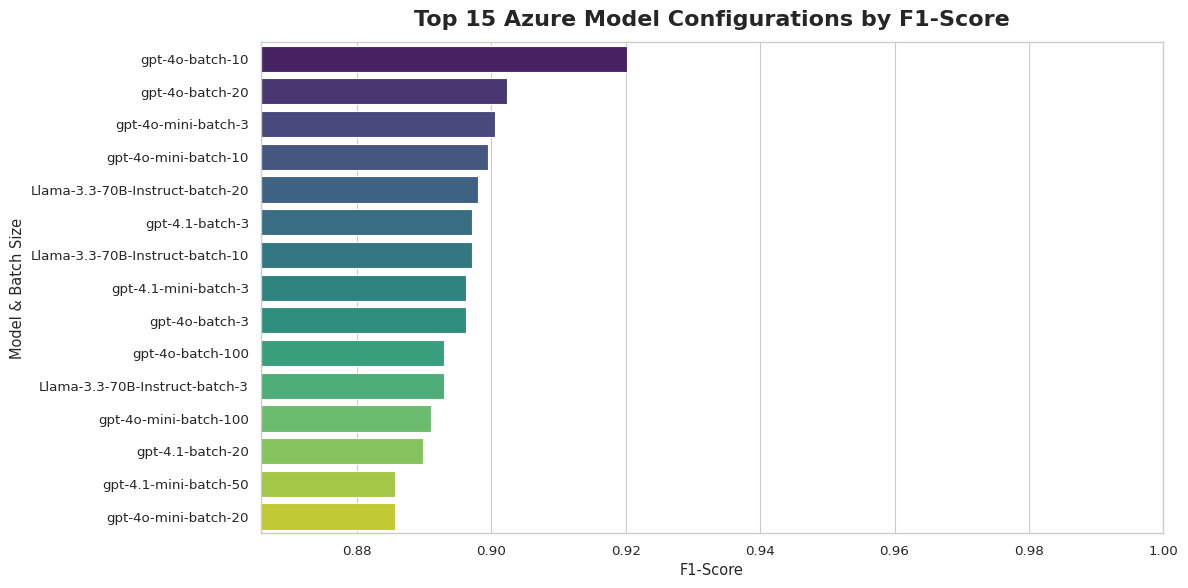

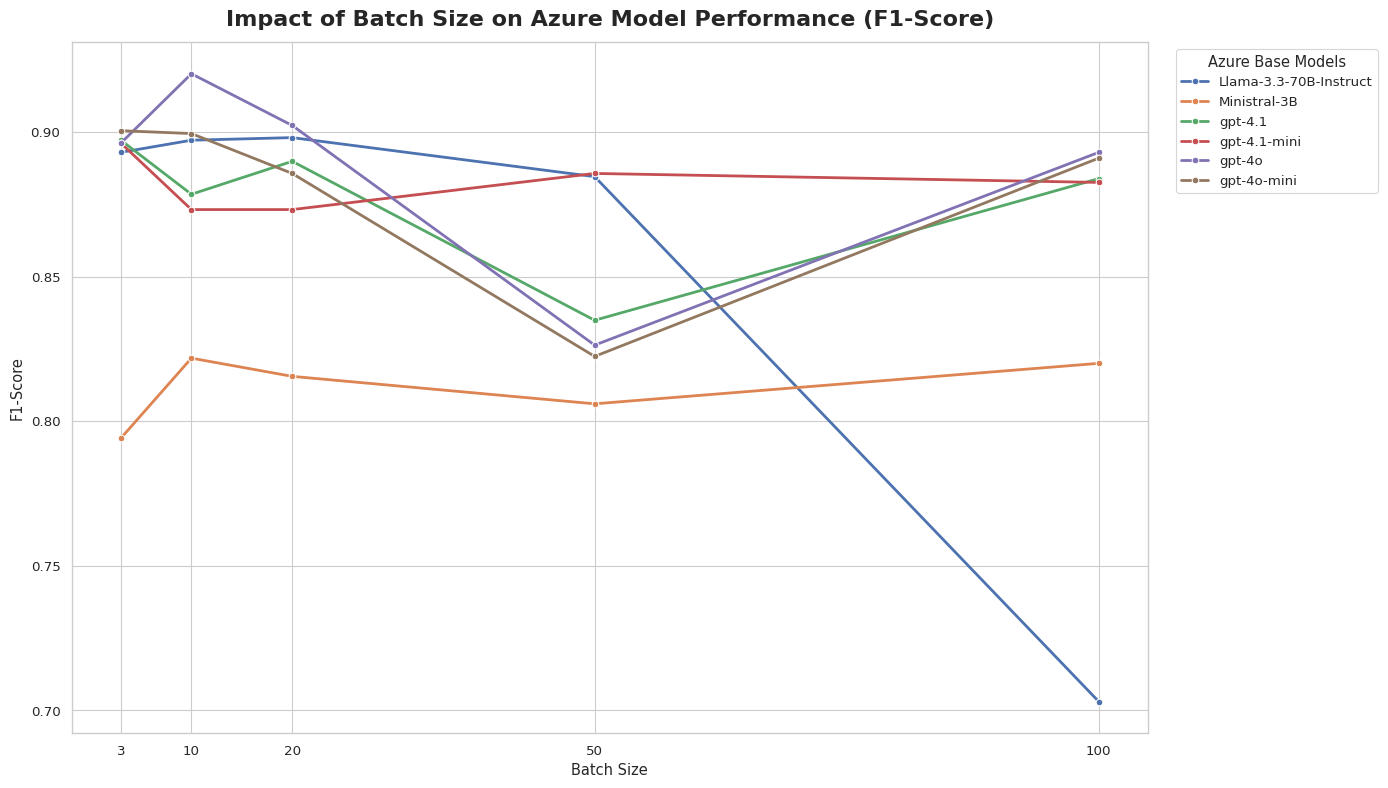

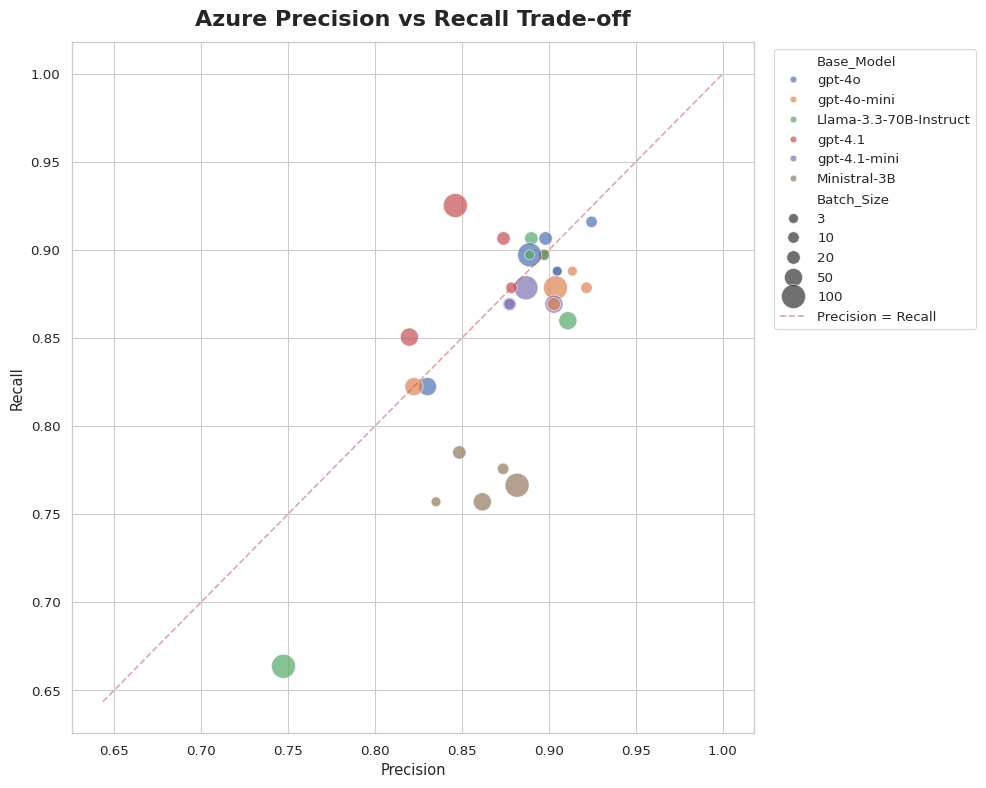

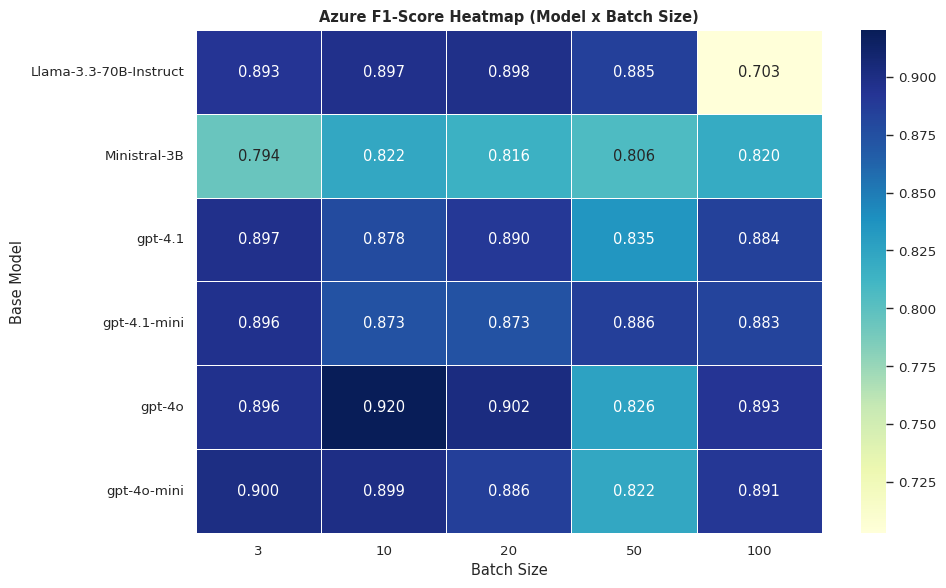

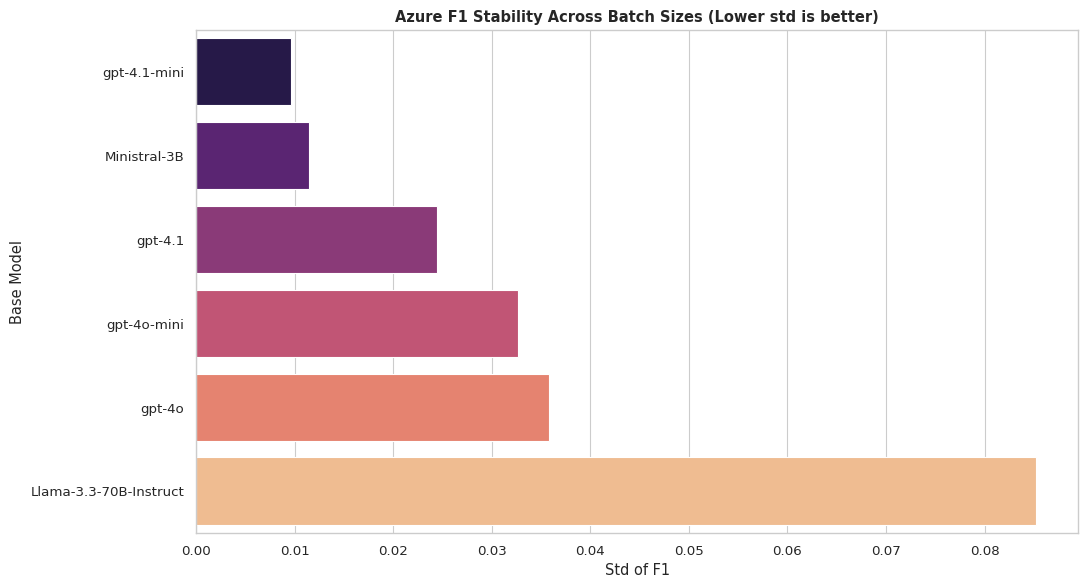

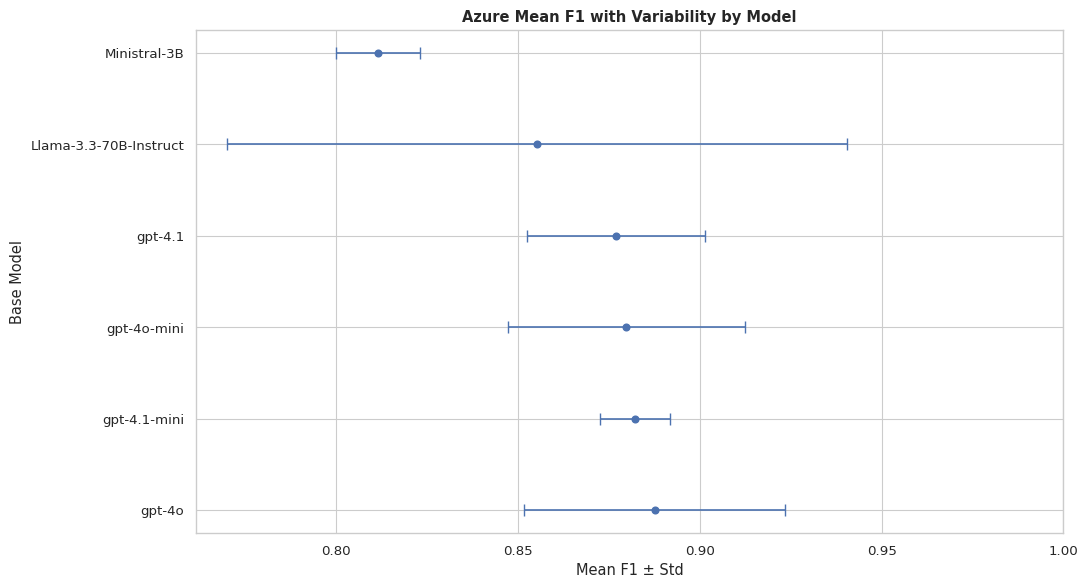

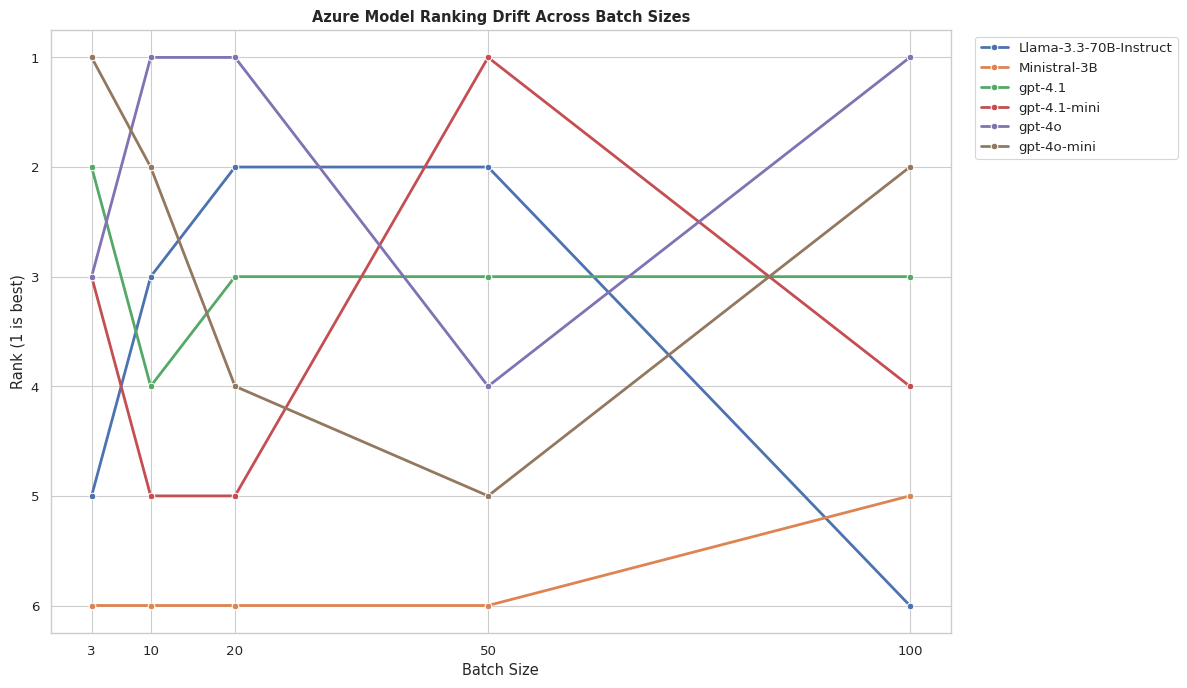

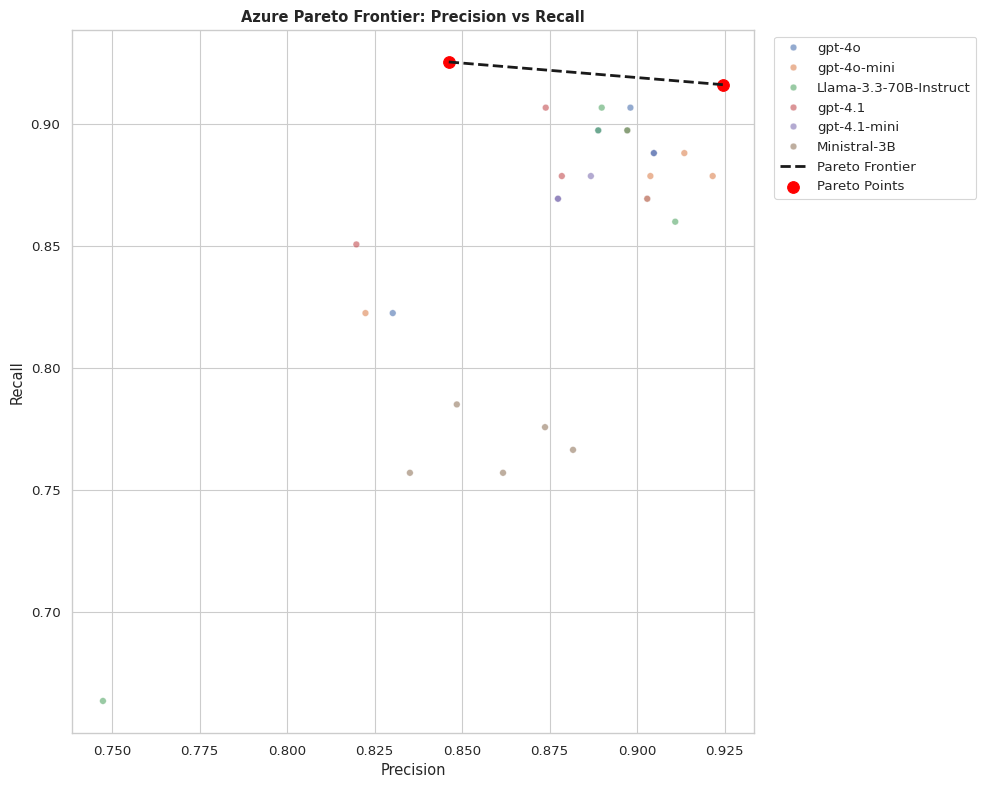

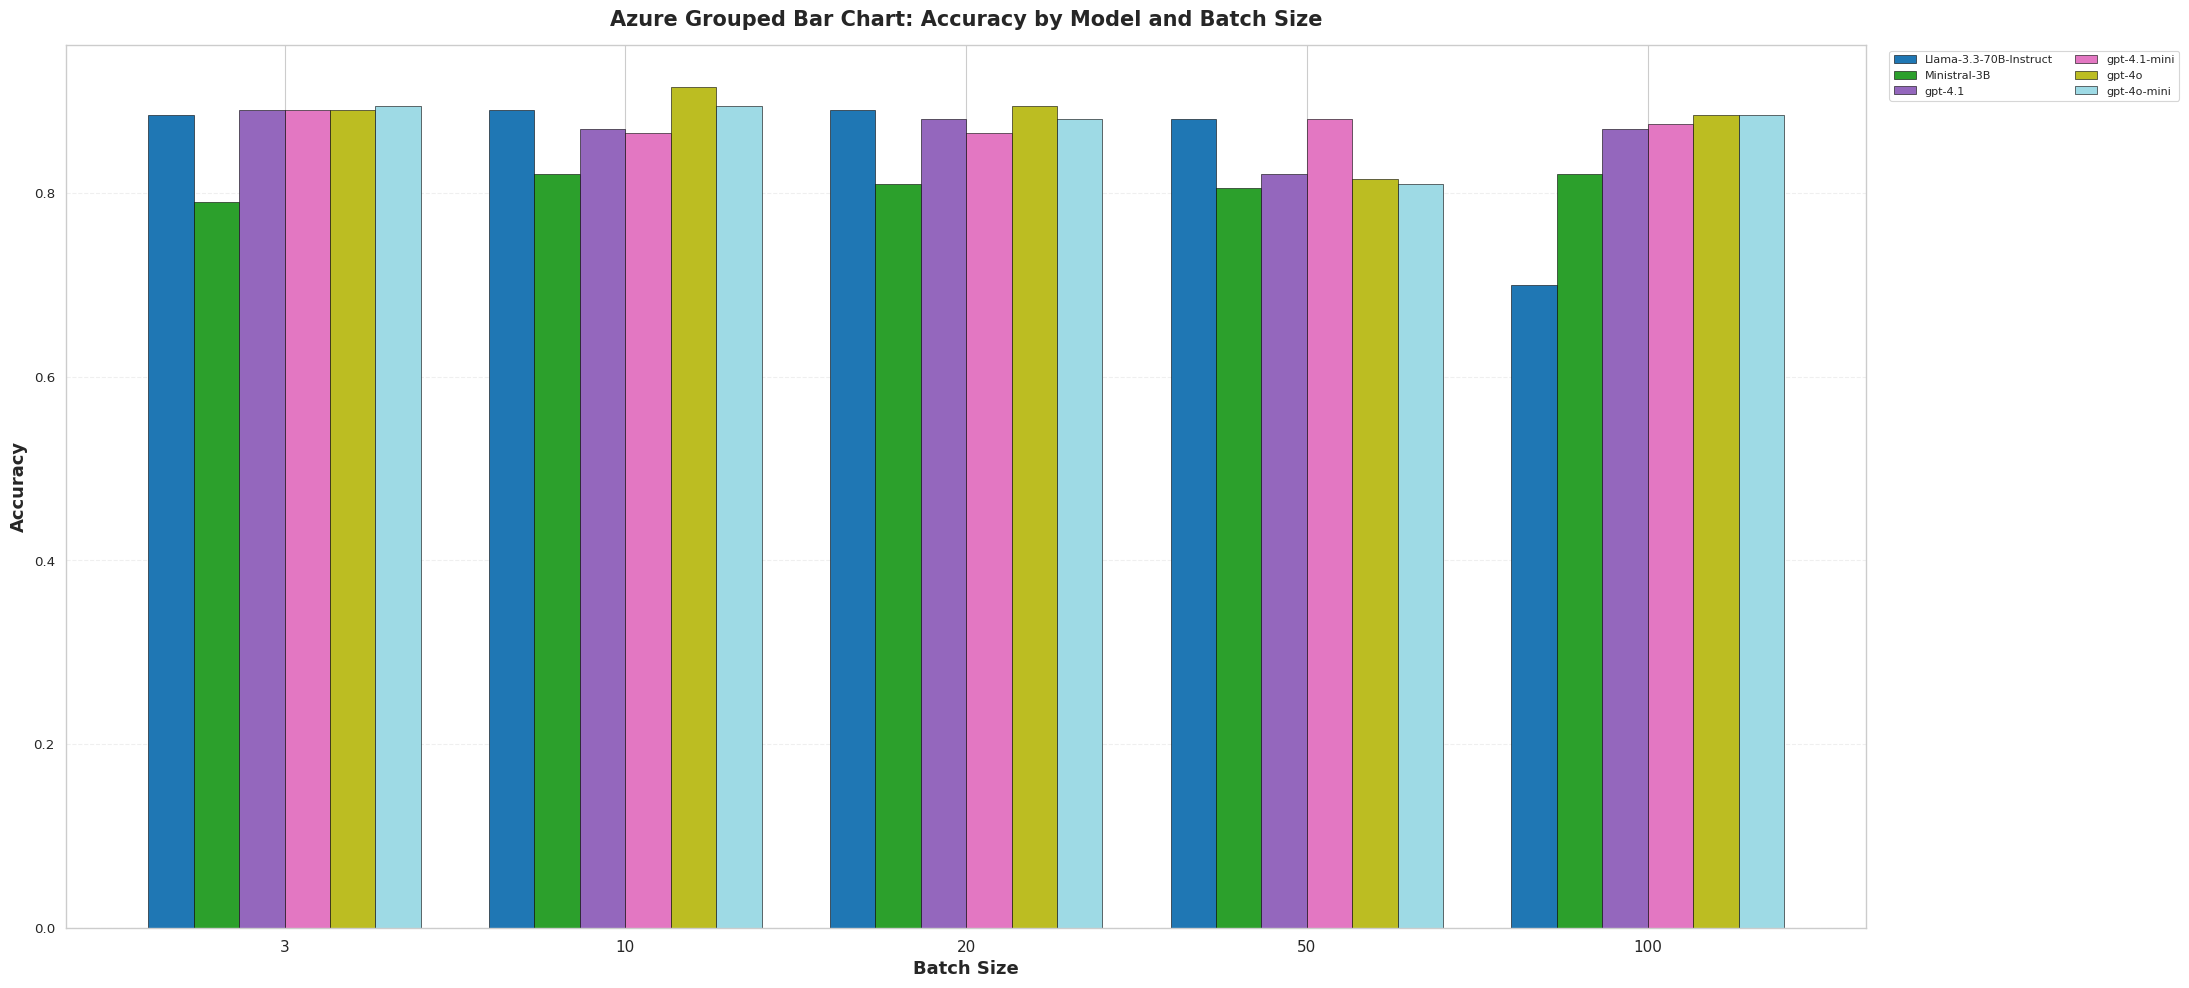

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load file
eval_file = "final_evaluation_metrics.csv"
if not os.path.exists(eval_file):
    raise FileNotFoundError(f"{eval_file} not found. Put it in the current working directory.")

df = pd.read_csv(eval_file)

# Validate required columns (now including Provider)
required_cols = ["Model_File", "Provider", "Accuracy", "Precision", "Recall", "F1-Score"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Filter data to keep ONLY Azure models
df = df[df["Provider"] == "Azure"].copy()

if df.empty:
    raise ValueError("No Azure models found in the dataset after filtering. Cannot generate plots.")

# Extract base model and batch size
df["Base_Model"] = df["Model_File"].str.replace(r"-batch-\d+$", "", regex=True)
df["Batch_Size"] = df["Model_File"].str.extract(r"batch-(\d+)").astype(float).fillna(0).astype(int)

# Sort by F1 for ranking-style plots
df = df.sort_values("F1-Score", ascending=False).reset_index(drop=True)

# Theme
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# 1) Top 15 configurations by F1
plt.figure(figsize=(12, 6))
top_15 = df.head(15).copy()
sns.barplot(data=top_15, x="F1-Score", y="Model_File", hue="Model_File", palette="viridis", legend=False)
plt.title("Top 15 Azure Model Configurations by F1-Score", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("F1-Score")
plt.ylabel("Model & Batch Size")
min_f1 = max(0, top_15["F1-Score"].min() - 0.02)
plt.xlim(min_f1, 1.0)
plt.tight_layout()
plt.show()

# 2) Impact of batch size on F1
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df.sort_values(["Base_Model", "Batch_Size"]),
    x="Batch_Size",
    y="F1-Score",
    hue="Base_Model",
    marker="o",
    linewidth=2
)
plt.title("Impact of Batch Size on Azure Model Performance (F1-Score)", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Batch Size")
plt.ylabel("F1-Score")
plt.xticks(sorted(df["Batch_Size"].unique()))
plt.legend(title="Azure Base Models", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3) Precision vs Recall scatter
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x="Precision",
    y="Recall",
    hue="Base_Model",
    size="Batch_Size",
    sizes=(50, 300),
    alpha=0.7
)
min_val = min(df["Precision"].min(), df["Recall"].min()) - 0.02
plt.plot([min_val, 1], [min_val, 1], "r--", alpha=0.5, label="Precision = Recall")
plt.title("Azure Precision vs Recall Trade-off", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 4) Heatmap: F1 by model x batch
pivot_f1 = df.pivot_table(index="Base_Model", columns="Batch_Size", values="F1-Score", aggfunc="mean")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=0.5)
plt.title("Azure F1-Score Heatmap (Model x Batch Size)", fontweight="bold")
plt.xlabel("Batch Size")
plt.ylabel("Base Model")
plt.tight_layout()
plt.show()

# 5) Stability bar: std F1 per model
stability = df.groupby("Base_Model")["F1-Score"].agg(["mean", "std"]).reset_index().sort_values("std")
plt.figure(figsize=(11, 6))
sns.barplot(data=stability, x="std", y="Base_Model", hue="Base_Model", palette="magma", legend=False)
plt.title("Azure F1 Stability Across Batch Sizes (Lower std is better)", fontweight="bold")
plt.xlabel("Std of F1")
plt.ylabel("Base Model")
plt.tight_layout()
plt.show()

# 6) Mean +- std errorbar for F1
summary = df.groupby("Base_Model")["F1-Score"].agg(["mean", "std"]).reset_index().sort_values("mean", ascending=False)
plt.figure(figsize=(11, 6))
plt.errorbar(summary["mean"], summary["Base_Model"], xerr=summary["std"], fmt="o", capsize=4)
plt.title("Azure Mean F1 with Variability by Model", fontweight="bold")
plt.xlabel("Mean F1 ± Std")
plt.ylabel("Base Model")
plt.xlim(max(0, summary["mean"].min() - 0.05), 1.0)
plt.tight_layout()
plt.show()

# 7) Ranking drift across batch sizes
rank_df = df.copy()
rank_df["Rank_in_Batch"] = rank_df.groupby("Batch_Size")["F1-Score"].rank(ascending=False, method="min")
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=rank_df.sort_values(["Base_Model", "Batch_Size"]),
    x="Batch_Size",
    y="Rank_in_Batch",
    hue="Base_Model",
    marker="o",
    linewidth=2
)
plt.gca().invert_yaxis()
plt.title("Azure Model Ranking Drift Across Batch Sizes", fontweight="bold")
plt.xlabel("Batch Size")
plt.ylabel("Rank (1 is best)")
plt.xticks(sorted(df["Batch_Size"].unique()))
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 8) Pareto frontier (maximize Precision and Recall)
pr = df[["Model_File", "Base_Model", "Batch_Size", "Precision", "Recall"]].dropna().copy()
points = pr[["Precision", "Recall"]].values
is_pareto = np.ones(points.shape[0], dtype=bool)

for i, p in enumerate(points):
    if not is_pareto[i]:
        continue
    dominates_i = np.all(points >= p, axis=1) & np.any(points > p, axis=1)
    if np.any(dominates_i):
        is_pareto[i] = False

pr["Pareto"] = is_pareto

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pr, x="Precision", y="Recall", hue="Base_Model", alpha=0.6)
pareto_pts = pr[pr["Pareto"]].sort_values("Precision")
plt.plot(pareto_pts["Precision"], pareto_pts["Recall"], "k--", linewidth=2, label="Pareto Frontier")
plt.scatter(pareto_pts["Precision"], pareto_pts["Recall"], c="red", s=70, label="Pareto Points")
plt.title("Azure Pareto Frontier: Precision vs Recall", fontweight="bold")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 9) Grouped bar chart (Accuracy by Model and Batch Size)
bar_df = df[["Base_Model", "Batch_Size", "Accuracy"]].copy()
bar_df = bar_df.sort_values(["Batch_Size", "Base_Model"])
batch_sizes = sorted(bar_df["Batch_Size"].unique())
models = sorted(bar_df["Base_Model"].unique())
n_models = len(models)

x = np.arange(len(batch_sizes))
bar_width = 0.8 / max(n_models, 1)

fig, ax = plt.subplots(figsize=(22, 10))
colors = plt.cm.tab20(np.linspace(0, 1, n_models))

for i, (model, color) in enumerate(zip(models, colors)):
    model_data = bar_df[bar_df["Base_Model"] == model].set_index("Batch_Size")
    y = [model_data["Accuracy"].get(bs, np.nan) for bs in batch_sizes]
    ax.bar(x + i * bar_width, y, width=bar_width, label=model, color=color, edgecolor="black", linewidth=0.4)

ax.set_xlabel("Batch Size", fontsize=13, fontweight="bold")
ax.set_ylabel("Accuracy", fontsize=13, fontweight="bold")
ax.set_title("Azure Grouped Bar Chart: Accuracy by Model and Batch Size", fontsize=15, fontweight="bold", pad=14)
ax.set_xticks(x + bar_width * (n_models - 1) / 2)
ax.set_xticklabels([str(bs) for bs in batch_sizes], fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, ncol=2, frameon=True)

plt.tight_layout()
plt.show()